<xarray.Dataset> Size: 49MB
Dimensions:  (time: 120, dir: 24, freq: 30, lat: 13, lon: 11)
Coordinates:
  * time     (time) datetime64[ns] 960B 2020-04-01 ... 2020-04-30T18:00:00
  * dir      (dir) float64 192B 187.5 202.5 217.5 232.5 ... 142.5 157.5 172.5
  * freq     (freq) float64 240B 0.03453 0.03798 0.04178 ... 0.4527 0.498 0.5478
  * lat      (lat) float64 104B 6.0 5.5 5.0 4.5 4.0 3.5 ... 2.0 1.5 1.0 0.5 0.0
  * lon      (lon) float64 88B 95.0 95.5 96.0 96.5 97.0 ... 98.5 99.0 99.5 100.0
Data variables:
    efth     (time, dir, freq, lat, lon) float32 49MB dask.array<chunksize=(120, 24, 30, 13, 11), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-15T09:50 GRIB to CDM+CF via cfgrib-0.9.1...

Total coordinate

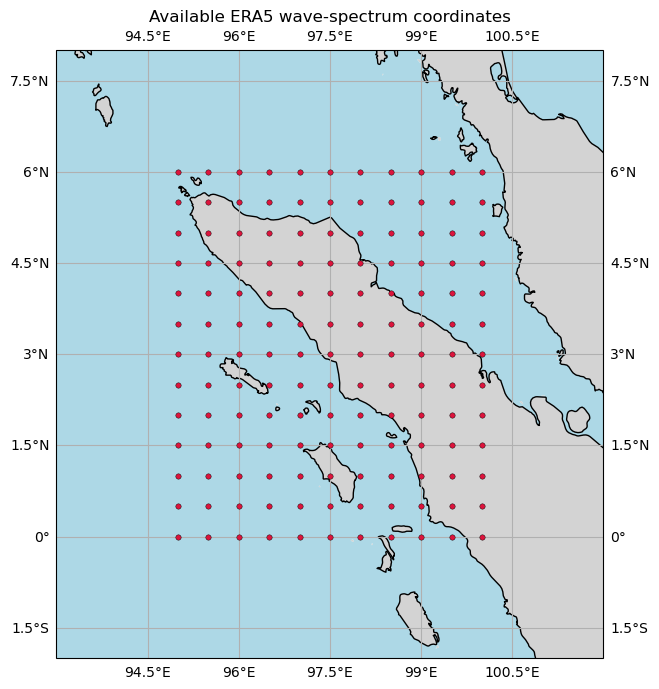

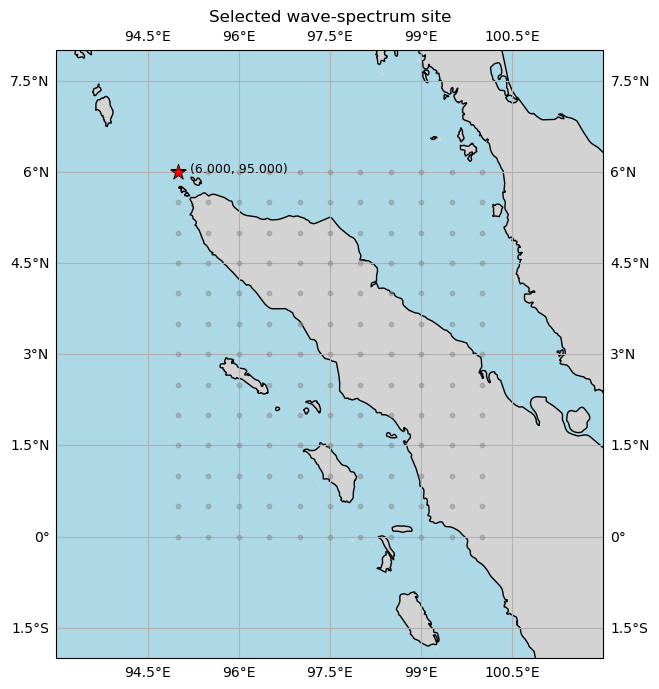

In [66]:
"""
Show all coordinate locations (lat/lon) available in an ERA5 wave-spectrum
dataset read with wavespectra.

Works for both dataset layouts:
    - gridded spectra:  dims (time, lat, lon, freq, dir)
    - point/site spectra: dims (time, site, freq, dir)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from wavespectra import read_era5


def get_coordinates(dset):
    """
    Return a DataFrame of all unique (lat, lon) coordinates in the dataset,
    handling both gridded and site-based layouts.
    """
    if "site" in dset.dims:
        # Point/site-based dataset: lat/lon vary along the 'site' dimension
        lats = dset.lat.values
        lons = dset.lon.values
        sites = dset.site.values if "site" in dset.coords else np.arange(len(lats))
        df = pd.DataFrame({"site": sites, "lat": lats, "lon": lons})
    else:
        # Gridded dataset: lat/lon are independent dimensions -> build the mesh
        lats = dset.lat.values
        lons = dset.lon.values
        lon_grid, lat_grid = np.meshgrid(lons, lats)
        df = pd.DataFrame({
            "lat": lat_grid.ravel(),
            "lon": lon_grid.ravel(),
        })

    return df.reset_index(drop=True)


def normalize_longitudes(lons, to_range="-180_180"):
    """
    Convert longitudes between 0-360 and -180/180 conventions.
    ERA5 grids commonly use 0-360; most mapping libraries expect -180/180.
    """
    lons = np.asarray(lons, dtype=float)
    if to_range == "-180_180":
        return ((lons + 180) % 360) - 180
    elif to_range == "0_360":
        return lons % 360
    else:
        raise ValueError("to_range must be '-180_180' or '0_360'")


# --- Shared layout settings so every map uses the same figure size, ---
# --- projection, land/ocean styling, and gridline scale -----------------
MAP_FIGSIZE = (10, 7)
MAP_PAD = 2  # degrees of padding added around the data extent


def get_map_extent(df, pad=MAP_PAD):
    """
    Compute a single [lon_min, lon_max, lat_min, lat_max] extent from a
    coordinate DataFrame. Reusing the SAME extent across plots is what
    keeps their layout and grid scale identical.
    """
    return [
        df["lon"].min() - pad, df["lon"].max() + pad,
        df["lat"].min() - pad, df["lat"].max() + pad,
    ]


def create_base_map(extent, figsize=MAP_FIGSIZE):
    """
    Build a map axes with the shared styling (land/ocean colors, coastline,
    gridlines) and a fixed extent, so every map produced with this function
    lines up on the same geographic scale.
    """
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE)
    ax.gridlines(draw_labels=True)

    return fig, ax


def plot_coordinates(df, extent=None, title="Available ERA5 wave-spectrum coordinates"):
    """
    Plot all coordinates on a map with coastlines for geographic context.
    """
    if extent is None:
        extent = get_map_extent(df)

    fig, ax = create_base_map(extent)

    ax.scatter(
        df["lon"], df["lat"],
        s=15, color="crimson", edgecolor="black", linewidth=0.3,
        transform=ccrs.PlateCarree(), zorder=5,
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_selected_site(df, site_lat, site_lon, extent=None,
                        title="Selected wave-spectrum site"):
    """
    Plot the selected site highlighted against all available coordinates,
    using the SAME extent/scale as plot_coordinates() so the two maps are
    directly comparable.
    """
    if extent is None:
        extent = get_map_extent(df)

    fig, ax = create_base_map(extent)

    # All available coordinates, shown faint for context
    ax.scatter(
        df["lon"], df["lat"],
        s=10, color="gray", alpha=0.4,
        transform=ccrs.PlateCarree(), zorder=4,
    )

    # The selected site, highlighted
    ax.scatter(
        site_lon, site_lat,
        s=140, marker="*", color="red", edgecolor="black", linewidth=0.6,
        transform=ccrs.PlateCarree(), zorder=6,
    )
    ax.text(
        site_lon + 0.2, site_lat, f"({site_lat:.3f}, {site_lon:.3f})",
        transform=ccrs.PlateCarree(), fontsize=9, zorder=6,
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def main(nc_path, site_lat=None, site_lon=None):
    # Step 1 — read the dataset
    dset = read_era5(nc_path)
    print(dset)

    # Step 2 — extract all coordinates
    coords_df = get_coordinates(dset)

    # Normalize longitude convention for plotting (ERA5 is often 0-360)
    coords_df["lon"] = normalize_longitudes(coords_df["lon"], to_range="-180_180")

    print(f"\nTotal coordinate points: {len(coords_df)}")
    print(coords_df.head(20))

    # Step 3 — save the full coordinate table
    coords_df.to_csv("era5_coordinates.csv", index=False)
    print("\nSaved full coordinate list to era5_coordinates.csv")

    # Step 4 — compute one shared extent used by BOTH maps below
    shared_extent = get_map_extent(coords_df)

    # Step 5 — plot all coordinates on a map
    plot_coordinates(coords_df, extent=shared_extent)

    # Step 6 — plot the selected site on a map with the same layout/scale
    if site_lat is not None and site_lon is not None:
        site_lon_norm = normalize_longitudes([site_lon], to_range="-180_180")[0]
        plot_selected_site(coords_df, site_lat, site_lon_norm, extent=shared_extent)


if __name__ == "__main__":
    # Replace with the path to your ERA5 wave-spectrum NetCDF file
    NC_FILE = "output.nc"

    # Optionally set the coordinates of the site you selected earlier
    # (e.g. the same target_lat / target_lon used with dset.sel(..., method="nearest"))
    SITE_LAT = 6
    SITE_LON = 95

    main(NC_FILE, site_lat=SITE_LAT, site_lon=SITE_LON)

In [67]:
# --- Cell: select the nearest site to your target coordinate ---
def select_nearest_site(dset, lat, lon):
    """Return the data at the coordinate nearest (lat, lon), for gridded or site-based datasets."""
    if "site" in dset.dims:
        dist = (dset.lat - lat) ** 2 + (dset.lon - lon) ** 2
        idx = int(dist.argmin())
        return dset.isel(site=idx)
    else:
        return dset.sel(lat=lat, lon=lon, method="nearest")

site_ds = select_nearest_site(dset, SITE_LAT, SITE_LON)
print(f"Selected point -> lat: {float(site_ds.lat):.3f}, lon: {float(site_ds.lon):.3f}")

Selected point -> lat: 6.000, lon: 95.000


In [68]:
# --- Cell: how long a record is held at this site ---
time_vals = pd.to_datetime(site_ds.time.values)

start_time = time_vals.min()
end_time = time_vals.max()
duration = end_time - start_time
n_steps = len(time_vals)
step_freq = pd.infer_freq(time_vals)

print(f"Start:            {start_time}")
print(f"End:              {end_time}")
print(f"Duration:         {duration}")
print(f"Number of steps:  {n_steps}")
print(f"Time step:        {step_freq if step_freq else 'irregular / not inferable'}")

Start:            2020-04-01 00:00:00
End:              2020-04-30 18:00:00
Duration:         29 days 18:00:00
Number of steps:  120
Time step:        6h


In [69]:
# --- Cell: compute ALL wave parameters at this site ---
# Common wavespectra stats — add/remove as needed
stats_list = ["hs", "tp", "tm01", "tm02", "dpm", "dspr", "dp", "dm", "gamma"]

wave_stats = site_ds.spec.stats(stats_list)      # returns an xarray Dataset (time-indexed)
wave_stats_df = wave_stats.to_dataframe()

print(wave_stats_df.describe())      # summary stats (mean, min, max, std, etc.)
wave_stats_df.head(10)

         lat    lon          hs          tp        tm01        tm02  \
count  120.0  120.0  120.000000  120.000000  120.000000  120.000000   
mean     6.0   95.0    1.303371   13.991686    9.080328    7.601027   
std      0.0    0.0    0.239586    1.449790    1.432627    1.352792   
min      6.0   95.0    0.918711   11.443369    5.743908    4.704698   
25%      6.0   95.0    1.096986   12.681391    8.226764    6.657871   
50%      6.0   95.0    1.248331   13.973260    9.217868    7.722516   
75%      6.0   95.0    1.491119   14.646853   10.076037    8.640726   
max      6.0   95.0    1.957589   18.769022   12.156586   10.685140   

              dpm        dspr          dp          dm       gamma  
count  120.000000  120.000000  120.000000  120.000000  120.000000  
mean   206.195663   34.924326  203.125000  203.464217    1.395087  
std      7.186717   10.969675   12.359505    5.238332    0.367884  
min    190.941055   21.584341  187.500000  190.173191    1.000000  
25%    200.894009   

,lat,lon,hs,tp,tm01,tm02,dpm,dspr,dp,dm,gamma
time,,,,,,,,,,,
2020-04-01 00:00:00,6.0,95.0,0.918711,12.340301,8.448998,6.883355,201.122025,39.071354,202.5,200.803319,1.667465
2020-04-01 06:00:00,6.0,95.0,0.985470,12.259501,8.587324,6.924424,201.005844,38.106156,202.5,200.896580,1.621768
2020-04-01 12:00:00,6.0,95.0,1.022056,12.257005,9.294087,7.699347,201.112778,33.431261,202.5,200.934757,1.601225
2020-04-01 18:00:00,6.0,95.0,1.031200,12.210076,9.823633,8.369930,201.088486,30.348044,202.5,200.842360,1.556655
2020-04-02 00:00:00,6.0,95.0,1.038749,12.173965,10.297460,8.889433,200.805237,28.095787,202.5,201.443864,1.343589
2020-04-02 06:00:00,6.0,95.0,1.060446,12.172268,10.574510,9.036369,200.227310,26.886099,202.5,202.371917,1.121005
2020-04-02 12:00:00,6.0,95.0,1.055204,17.897844,10.818108,9.344463,209.641266,26.113521,217.5,202.660692,1.000000
2020-04-02 18:00:00,6.0,95.0,1.077722,17.367168,10.922392,9.247231,210.033279,26.829845,217.5,203.356522,1.190418
2020-04-03 00:00:00,6.0,95.0,1.109550,16.621033,11.303096,9.649596,210.233444,26.451772,217.5,204.932789,1.716635


Saved to selected_site_wave_stats.csv


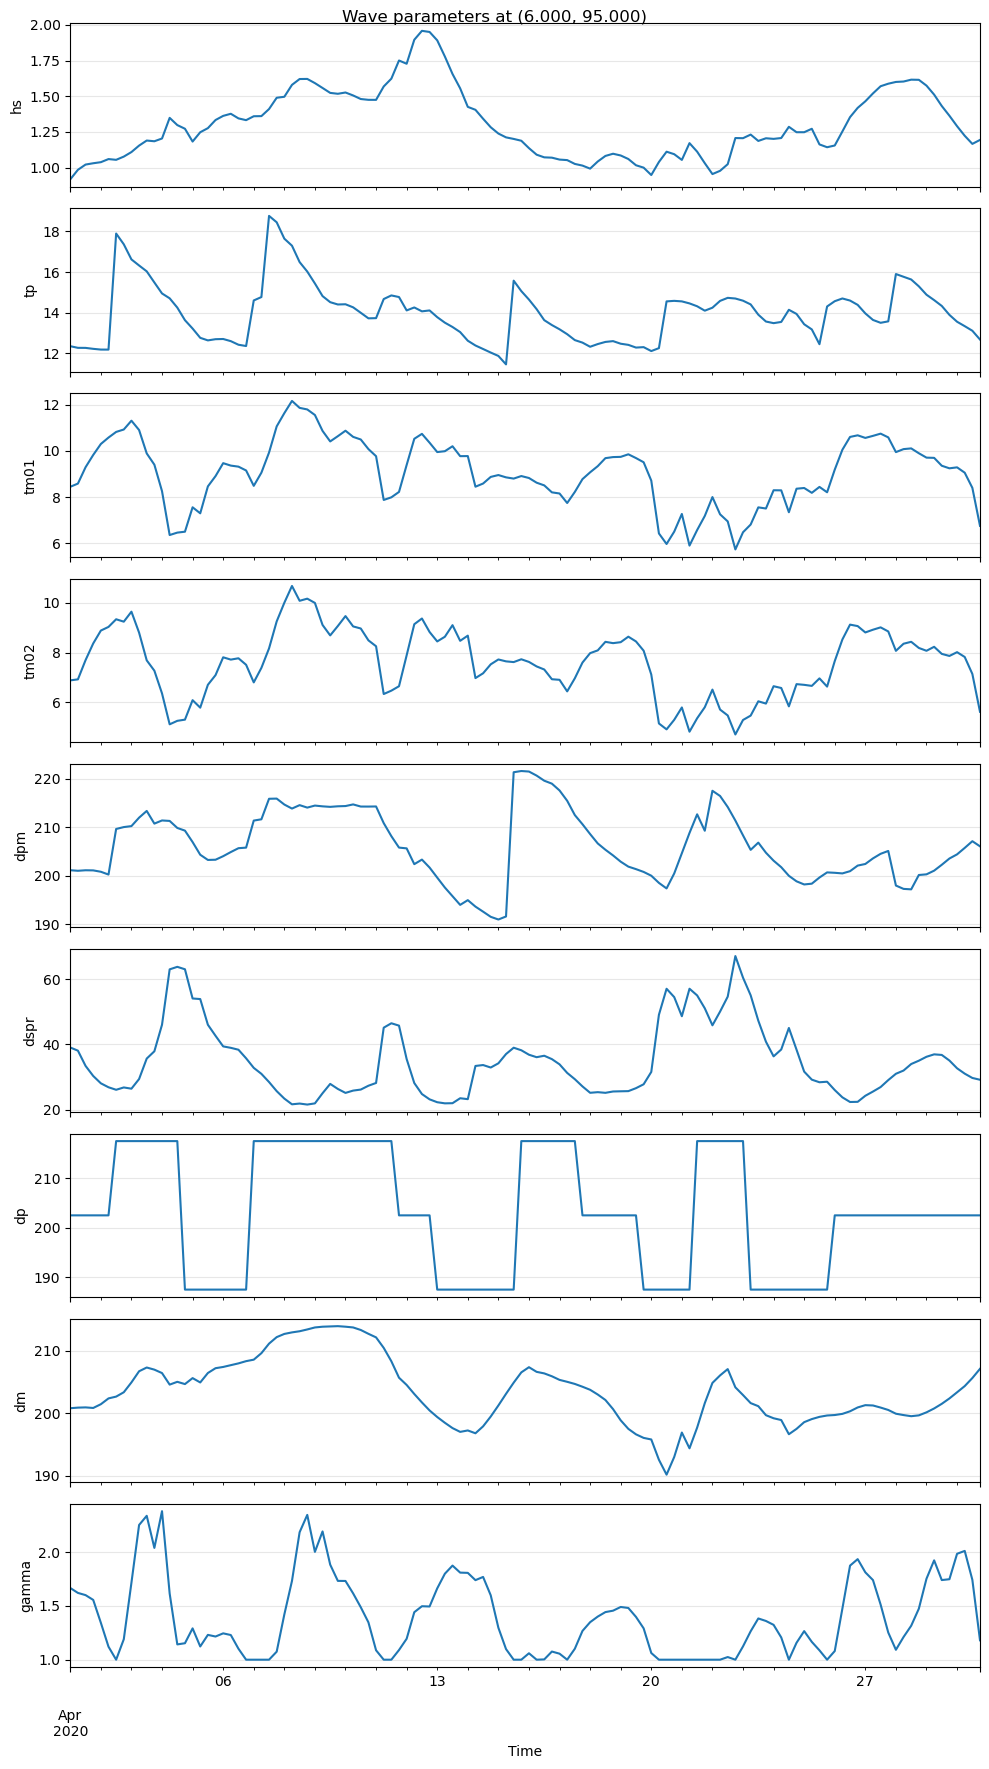

In [70]:
# --- Cell: save + plot the wave-parameter time series ---
wave_stats_df.to_csv("selected_site_wave_stats.csv")
print("Saved to selected_site_wave_stats.csv")

fig, axes = plt.subplots(len(stats_list), 1, figsize=(10, 2 * len(stats_list)), sharex=True)
for ax, stat in zip(axes, stats_list):
    wave_stats_df[stat].plot(ax=ax)
    ax.set_ylabel(stat)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Time")
fig.suptitle(f"Wave parameters at ({float(site_ds.lat):.3f}, {float(site_ds.lon):.3f})")
plt.tight_layout()
plt.show()